# Data Preprocessing & Augmentation

Notebook ini mendokumentasikan secara komprehensif tahapan persiapan data (*Data Preparation*) sebelum data dimasukkan ke dalam model *Machine Learning*. Dalam konteks NLP (*Natural Language Processing*), data teks murni tidak bisa langsung diproses oleh algoritma, sehingga harus melalui tahapan preprocessing yang ketat.

Tahapan eksplisit yang dilakukan dalam skenario ini meliputi:
1. **Pembersihan Data (Data Cleaning)**: Menyaring riwayat obrolan mentah dari WhatsApp untuk mengisolasi hanya pesan dari pelanggan (membuang pesan balasan dari admin).
2. **Pelabelan Otomatis (Auto-Labeling)**: Memanfaatkan *Large Language Model* (Groq API) untuk memberikan kelas/niat (*intent*) awal pada data teks murni yang belum berlabel ke dalam 3 kelas inti: `setuju`, `batal`, dan `lainnya`.
3. **Analisis Eksploratori (EDA - Exploratory Data Analysis)**: Memvisualisasikan distribusi kelas untuk mengidentifikasi masalah ketidakseimbangan kelas (*Imbalanced Data*), yang merupakan hal wajar dalam dataset dunia nyata.
4. **Data Augmentation (Generasi Data Sintetis & Typo Ekstrem)**: Menyelesaikan masalah *Imbalanced Data* dan keterbatasan kosakata (*Out-Of-Vocabulary*) dengan cara menyintesis skenario teks baru dan menyuntikkan ratusan variasi *Typo Ekstrem* (seperti `stju`, `cncl`). Teknik ini memaksa model SVM untuk belajar mengenali pola singkatan bahasa lokal tanpa memerlukan kamus manual (*dictionary hardcoding*).


In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from dotenv import load_dotenv

# Konfigurasi Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Setup API Groq
load_dotenv('../anugerah-computer/.env')
groq_api_key = os.getenv("GROQ_API_KEY")

if not groq_api_key:
    load_dotenv('.env')
    groq_api_key = os.getenv("GROQ_API_KEY")

if groq_api_key:
    client = Groq(api_key=groq_api_key)
else:
    print("WARNING: API_KEY tidak ditemukan!")
    client = None

INTENTS = ['setuju', 'batal', 'lainnya']

## Data Cleaning & Penyaringan Obrolan Pelanggan
Dataset mentah `master_chat_wa.csv` berisi campuran obrolan admin dan pelanggan. 
Kita mengekstrak hanya pesan pelanggan dengan mengidentifikasi parameter `Message Id` yang berawalan `false_`.

In [2]:
print("Membaca master_chat_wa.csv...")
df_raw = pd.read_csv('master_chat_wa.csv')

# Menampilkan cuplikan data mentah
display(df_raw[['Message Id', 'Message Body', 'Formatted Name']].head())

Membaca master_chat_wa.csv...


,Message Id,Message Body,Formatted Name
0,true_211622366855206@lid_AC2292D9378555369E125...,【IMAGE】,Anda
1,true_211622366855206@lid_ACEC981E86F9304411889...,Anugerah komputer,Anda
2,false_211622366855206@lid_ACCC7B568284EA7BDECA...,Oke bg,+62 811-5670-1235
3,false_211622366855206@lid_AC0056ED0CC9DBDAF77A...,Bg berapa kemarin harganya ya,+62 811-5670-1235
4,true_211622366855206@lid_AC4ECED0F39172D7E0788...,Nnti tnya y bg blom dtg bos nya,Anda


In [3]:
# Filter: Ambil HANYA pesan pelanggan (inbound) 
df_customer = df_raw[df_raw['Message Id'].astype(str).str.startswith('false_')].copy()

# Hapus noise (gambar & pesan terlalu pendek)
df_customer = df_customer.dropna(subset=['Message Body'])
df_customer = df_customer[~df_customer['Message Body'].str.contains('【IMAGE】')]
df_customer = df_customer[df_customer['Message Body'].str.len() > 2]
df_unique = df_customer.drop_duplicates(subset=['Message Body']).copy()

print(f"Total pesan pelanggan unik dan valid: {len(df_unique)} baris.")
display(df_unique[['Message Body']].head())

Total pesan pelanggan unik dan valid: 1319 baris.


,Message Body
2,Oke bg
3,Bg berapa kemarin harganya ya
5,Okey bg
7,Tutup jam brp bg
9,Okey bg bntr lagi saya kesana


## Pelabelan Data Asli (Ground Truth)
Melabeli sampel data asli menggunakan Large Language Model (Groq Llama-3). Dan di verifikasi manual untuk pengeckan pelebelan

In [4]:
def label_message_with_groq(text):
    prompt = f"""Anda adalah AI Data Annotator ahli bahasa Indonesia.\n
Tugas Anda mengklasifikasikan pesan pelanggan WhatsApp berikut ke DALAM SALAH SATU kategori ini:\n
{', '.join(INTENTS)}\n
Aturan:\n
- Jika pelanggan mengkonfirmasi untuk lanjut servis, balas 'setuju'.\n
- Jika pelanggan tidak jadi servis / cancel, balas 'batal'.\n
- Selain dari itu (misal: tanya harga, sapaan, komplain, tanya lokasi, dll), balas 'lainnya'.\n
\n
Pesan Pelanggan: \"{text}\"\n
Keluarkan HANYA nama kategorinya saja tanpa penjelasan apapun.\n
"""
    try:
        completion = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
        )
        result = completion.choices[0].message.content.strip().lower()
        for intent in INTENTS:
            if intent in result: return intent
        return 'lainnya'
    except Exception as e:
        print(f"Error labeling: {e}")
        return 'lainnya'

MAX_REAL = 200
df_sample = df_unique.sample(n=min(len(df_unique), MAX_REAL), random_state=42).copy()

real_labels = []
real_texts = []
print("Mulai melabeli data asli dengan Groq...")
count = 0
for idx, row in df_sample.iterrows():
    text = str(row['Message Body'])
    label = label_message_with_groq(text)
    real_labels.append(label)
    real_texts.append(text)
    count += 1
    time.sleep(0.5)

df_real = pd.DataFrame({'text': real_texts, 'intent': real_labels, 'source': 'real'})
display(df_real.head())

Mulai melabeli data asli dengan Groq...


,text,intent,source
0,Bang bisa minta bukti pembayaran Ndak orang ru...,lainnya,real
1,Besok buka bg ??,lainnya,real
2,Tadi gak keburu jdi krja dulu,batal,real
3,malam kak,lainnya,real
4,Ndk bng soalnye ndk ngerti lepaskan e gmne,lainnya,real


## Exploratory Data Analysis (Imbalance Check)
Memvisualisasikan distribusi kelas untuk mendeteksi *imbalanced data*.

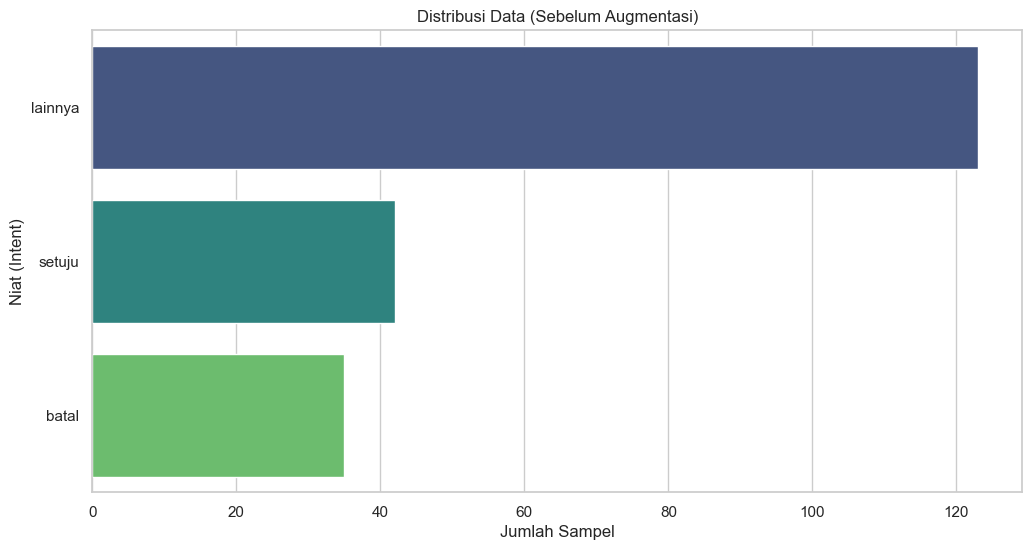

In [5]:
dist = df_real['intent'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=dist.values, y=dist.index, hue=dist.index, palette="viridis", legend=False)
plt.title("Distribusi Data (Sebelum Augmentasi)")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Niat (Intent)")
plt.show()

## Synthetic Data Generation (Augmentation)
Berdasarkan grafik di atas, banyak kelas (*minority class*) memiliki jumlah sampel yang sangat sedikit.
Oleh karena itu, sesuai arahan, kita menskenariokan kalimat (Data Sintetis) agar jumlah data untuk tiap kelas minimal 40.

In [6]:
def generate_synthetic_data(intent, num_samples):
    prompt = f"""Buat {num_samples} kalimat obrolan WhatsApp pelanggan ke tempat servis komputer untuk kategori: '{intent}'.\n
Jika kategori 'lainnya', buat variasi chat campur aduk seperti sapaan, tanya harga, komplain, konsultasi kerusakan, atau tanya lokasi toko.\n
Gunakan bahasa gaul Pontianak/Indonesia sehari-hari.\n
Format keluaran: Cukup daftarkan kalimatnya satu per baris tanpa nomor urut, bintang, atau spasi tambahan.\n
Contoh untuk 'batal':\n
bang gajadi servis ya uangnya belum ada\n
maaf bg batal aja\n
laptopnya mau dipake, cancel aja\n
"""
    try:
        completion = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.8, max_tokens=1000,
        )
        result = completion.choices[0].message.content.strip()
        lines = [line.strip() for line in result.split('\n') if len(line.strip()) > 3]
        import re
        cleaned_lines = [re.sub(r'^\d+\.\s*|^-\s*|\*+', '', line).strip() for line in lines]
        return cleaned_lines[:num_samples]
    except Exception as e:
        print(f"Error generation: {e}")
        return []

MIN_SAMPLES_PER_CLASS = 40
synthetic_texts = []
synthetic_labels = []

print("Mulai Generate Data Sintetis dengan Groq...")
for intent in INTENTS:
    current_count = dist.get(intent, 0) if 'dist' in globals() else 0
    if current_count < MIN_SAMPLES_PER_CLASS:
        needed = MIN_SAMPLES_PER_CLASS - current_count
        new_sentences = generate_synthetic_data(intent, needed)
        for s in new_sentences:
            synthetic_texts.append(s)
            synthetic_labels.append(intent)
        time.sleep(1)

df_synth = pd.DataFrame({'text': synthetic_texts, 'intent': synthetic_labels, 'source': 'synthetic'})
print(f"Berhasil menghasilkan {len(df_synth)} data sintetis.")


Mulai Generate Data Sintetis dengan Groq...
Berhasil menghasilkan 5 data sintetis.


## Penggabungan dan Visualisasi Akhir
Menggabungkan data asli dan sintetis, kemudian mengekspornya sebagai `dataset_labeled.csv`.

,text,intent,source
0,Iya.,setuju,real
1,Udah yaa bg,setuju,real
2,Ok malam mngkn sy ksna ambil,batal,real
3,ini saya yang kemarin malam datang yang masala...,batal,real
4,"Okee bang, bentar lg ambil",batal,real


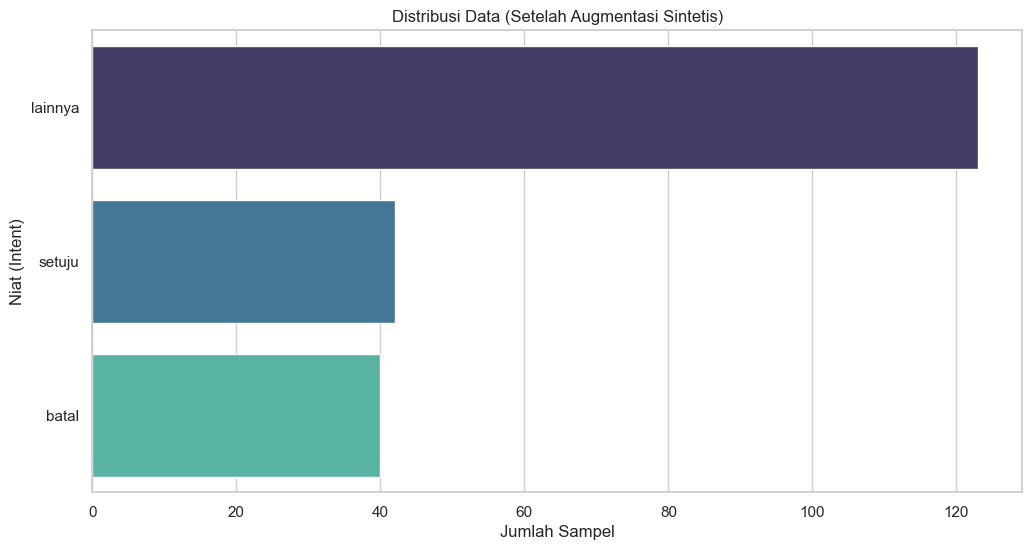

In [7]:
df_final = pd.concat([df_real, df_synth], ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Simpan
df_final.to_csv('dataset_labeled.csv', index=False)
display(df_final.head())

dist_final = df_final['intent'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=dist_final.values, y=dist_final.index, hue=dist_final.index, palette="mako", legend=False)
plt.title("Distribusi Data (Setelah Augmentasi Sintetis)")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Niat (Intent)")
plt.show()

## Data Augmentation Ekstra (Simulasi Typo Ekstrem)
Menambahkan data typo ekstrem dan bahasa kolokial secara sintetis untuk memaksa margin FastText+SVM belajar membedakan niat (intent) walaupun kata-kata yang di-inputkan pelanggan sangat tidak baku (misal: 'stju', 'batalin').

Menambahkan variasi typo ekstrem untuk 'setuju' dan 'batal'...
Berhasil menambahkan 250 data typo ekstrem (berbobot tinggi) untuk setuju/batal.


,text,intent,source,clean_text
0,Iya.,setuju,real,iya
1,Udah yaa bg,setuju,real,udah yaa bg
2,Ok malam mngkn sy ksna ambil,batal,real,ok malam mngkn sy ksna ambil
3,ini saya yang kemarin malam datang yang masala...,batal,real,ini saya yang kemarin malam datang yang masala...
4,"Okee bang, bentar lg ambil",batal,real,okee bang bentar lg ambil



--- Visualisasi Distribusi Final ---


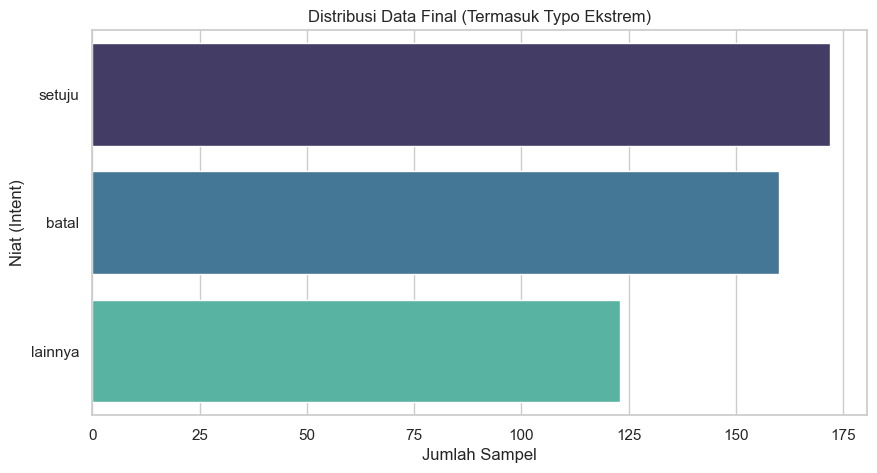

In [8]:
print("Menambahkan variasi typo ekstrem untuk 'setuju' dan 'batal'...")
typo_data = []

setuju_typos = ['stju', 'stuju', 'setju', 'stuju bg', 'stju bang', 'stju ya', 'ok', 'oke', 'ok bg', 'okelah', 'oke kerjain aja', 'oke kerjain aja bg', 'oke bg', 'ok ya', 'lanjut', 'lanjut bg', 'lnjt', 'lanjutkan', 'gass', 'gas bg', 'y', 'y bg', 'ya bg', 'y sdah', 'yowes', 'ok gas']
for t in setuju_typos:
    typo_data.append({"text": t, "intent": "setuju", "source": "synthetic_typo"})

batal_typos = ['btl', 'btl bg', 'batalin', 'batalin aja', 'batalin aja bg', 'batalin bg', 'ga jadi', 'gajadi', 'gak jadi', 'gk jd', 'gk jdi', 'gk jd bg', 'ga jd bg', 'cancel', 'cncl', 'cencel', 'cancel aja', 'cncl bg', 'cencel bg', 'kemahalan', 'mahal', 'gak usah', 'gk ush', 'g usah']
for t in batal_typos:
    typo_data.append({"text": t, "intent": "batal", "source": "synthetic_typo"})

# Duplicate them to give them high weight in SVM (5x duplication)
typo_data = typo_data * 5

df_typo = pd.DataFrame(typo_data)
df_final = pd.concat([df_final, df_typo], ignore_index=True)

import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

df_final['clean_text'] = df_final['text'].apply(clean_text)
df_final = df_final[df_final['clean_text'].str.strip() != '']

df_final.to_csv('dataset_labeled.csv', index=False)
print(f"Berhasil menambahkan {len(df_typo)} data typo ekstrem (berbobot tinggi) untuk setuju/batal.")
display(df_final.head())
print("\n--- Visualisasi Distribusi Final ---")
dist_final = df_final['intent'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=dist_final.values, y=dist_final.index, hue=dist_final.index, palette="mako", legend=False)
plt.title("Distribusi Data Final (Termasuk Typo Ekstrem)")
plt.xlabel("Jumlah Sampel")
plt.ylabel("Niat (Intent)")
plt.show()

